# Split Strategy Comparison

**Objective:** Compare four train/validation/test split strategies to identify the most appropriate one for this demand forecasting problem.

The dataset covers approximately one year of daily sales (December 2010 – December 2011). The short time span makes split strategy selection non-trivial: standard approaches may introduce either data leakage or severe distribution shift between train and test sets.

The four strategies evaluated are:
1. **Random Shuffle** — rows split randomly, ignoring time order
2. **Chronological** — strict temporal split (train = past, test = future)
3. **Block-Shuffled** — consecutive blocks of 14 days shuffled before assignment
4. **TimeSeriesSplit with gap** — rolling-origin cross-validation with a purge gap

Each strategy is evaluated using the same model (Random Forest) and the same features across all 5 selected categories.

## Step 1: Imports and Data Loading

In [3]:
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "lightgbm"])

0

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

daily = pd.read_csv(r"C:\Users\user\internship\daily_category_sales_clean.csv")
daily["Date"] = pd.to_datetime(daily["Date"])
daily = daily[daily["Category"] != "Miscellaneous"]

all_categories = daily["Category"].unique().tolist()

print("Dataset shape:", daily.shape)
print("Number of categories:", len(all_categories))
print("Date range:", daily["Date"].min().date(), "to", daily["Date"].max().date())

Dataset shape: (20196, 5)
Number of categories: 54
Date range: 2010-12-01 to 2011-12-09


## Step 2: Evaluation Function

A common evaluation function is defined once and reused across all splits and models.
Negative predictions are clipped to zero since demand cannot be negative.

In [6]:
def evaluate_forecast(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    y_pred = np.maximum(y_pred, 0)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    denominator = np.sum(np.abs(y_true))
    wape = (np.sum(np.abs(y_true - y_pred)) / denominator) * 100 if denominator > 0 else np.nan
    r2 = r2_score(y_true, y_pred)
    bias = np.mean(y_pred - y_true)
    return mae, rmse, wape, r2, bias

## Step 3: Split Functions

Four split strategies are defined:

- **Random Shuffle:** rows are randomly assigned to train/val/test — ignores time order completely.
- **Chronological:** data is sorted by date and split at fixed proportions — train on the past, test on the future.
- **Block-Shuffled:** consecutive blocks of 14 days are formed, then shuffled randomly before assignment — preserves local temporal structure while reducing distribution shift.
- **TimeSeriesSplit with gap:** rolling-origin cross-validation with a 35-day purge gap between train and test in each fold — zero leakage but produces small training sets on a 1-year dataset.

In [8]:
# 1. Random Shuffle
def random_split(data, random_state=42):
    train_val, test = train_test_split(
        data, test_size=0.15, random_state=random_state)
    train, val = train_test_split(
        train_val, test_size=0.176, random_state=random_state)
    return (train.reset_index(drop=True),
            val.reset_index(drop=True),
            test.reset_index(drop=True))

# 2. Chronological
def chronological_split(data, train_size=0.6, val_size=0.2):
    data = data.sort_values("Date").reset_index(drop=True)
    n = len(data)
    train_end = int(n * train_size)
    val_end = int(n * (train_size + val_size))
    return (data.iloc[:train_end].copy(),
            data.iloc[train_end:val_end].copy(),
            data.iloc[val_end:].copy())

# 3. Block-Shuffled
def block_shuffled_split(data, block_size=14, train_size=0.70,
                         val_size=0.15, random_state=42):
    data = data.sort_values("Date").reset_index(drop=True)
    n_blocks = int(np.ceil(len(data) / block_size))
    block_ids = np.repeat(np.arange(n_blocks), block_size)[:len(data)]
    data = data.copy()
    data["block_id"] = block_ids
    unique_blocks = data["block_id"].unique()
    rng = np.random.default_rng(random_state)
    rng.shuffle(unique_blocks)
    n_train = int(len(unique_blocks) * train_size)
    n_val = int(len(unique_blocks) * val_size)
    train_blocks = unique_blocks[:n_train]
    val_blocks = unique_blocks[n_train:n_train + n_val]
    test_blocks = unique_blocks[n_train + n_val:]
    train = data[data["block_id"].isin(train_blocks)].drop(
        columns="block_id").reset_index(drop=True)
    val = data[data["block_id"].isin(val_blocks)].drop(
        columns="block_id").reset_index(drop=True)
    test = data[data["block_id"].isin(test_blocks)].drop(
        columns="block_id").reset_index(drop=True)
    return train, val, test

# 4. TimeSeriesSplit with gap
def timeseries_cv_split(data, n_splits=3, gap=35):
    data = data.sort_values("Date").reset_index(drop=True)
    tscv = TimeSeriesSplit(n_splits=n_splits, gap=gap)
    folds = []
    for train_idx, test_idx in tscv.split(data):
        folds.append({
            "train": data.iloc[train_idx].reset_index(drop=True),
            "test": data.iloc[test_idx].reset_index(drop=True)
        })
    return folds


## Step 4: Dataset Preparation

For each selected category, a forecasting dataset is prepared with:
- A target variable representing total sales over the next X=7 days, computed Y=7 days in advance
- Lag features (lag_1 to lag_7, lag_14, lag_28)
- Rolling statistics (mean, std, min, max over 7, 14, 28-day windows)
- Calendar features (day of week, month)

> **Note:** All rolling features are computed using `.shift(1)` before `.rolling()` to ensure that only past information is used — today's sales value is never included in the features.

In [10]:
X_horizon = 7
Y_lead = 7
target_col = f"target_X{X_horizon}_Y{Y_lead}"

def prepare_dataset(daily_data, category_name, X=7, Y=7):
    df = (daily_data[daily_data["Category"] == category_name]
          .sort_values("Date").copy())
    df = df[["Date", "Category", "Quantity"]].reset_index(drop=True)

    # Target
    quantities = df["Quantity"].to_numpy()
    targets = []
    for i in range(len(df)):
        start = i + Y
        end = start + X
        targets.append(quantities[start:end].sum()
                       if end <= len(df) else np.nan)
    df[f"target_X{X}_Y{Y}"] = targets

    # Lag features
    for lag in list(range(1, 8)) + [14, 28]:
        df[f"lag_{lag}"] = df["Quantity"].shift(lag)

    # Rolling features (shifted by 1 to avoid leakage)
    shifted = df["Quantity"].shift(1)
    for window in [7, 14, 28]:
        df[f"rolling_mean_{window}"] = shifted.rolling(window).mean()
        df[f"rolling_std_{window}"]  = shifted.rolling(window).std()
        df[f"rolling_min_{window}"]  = shifted.rolling(window).min()
        df[f"rolling_max_{window}"]  = shifted.rolling(window).max()
        df[f"rolling_sum_{window}"]  = shifted.rolling(window).sum()

    # Calendar features
    df["day_of_week"] = df["Date"].dt.dayofweek
    df["month"]       = df["Date"].dt.month

    return df.dropna().reset_index(drop=True)

features = [
    "lag_1","lag_2","lag_3","lag_4","lag_5","lag_6","lag_7","lag_14","lag_28",
    "rolling_mean_7","rolling_mean_14","rolling_mean_28",
    "rolling_std_7","rolling_std_14","rolling_std_28",
    "rolling_min_7","rolling_min_14","rolling_min_28",
    "rolling_max_7","rolling_max_14","rolling_max_28",
    "rolling_sum_7","rolling_sum_14","rolling_sum_28",
    "day_of_week","month"
]

datasets = {}
for category in all_categories:
    datasets[category] = prepare_dataset(daily, category,
                                         X=X_horizon, Y=Y_lead)

## Step 5: Split Comparison — Fixed Model (Random Forest)

To select the best split strategy, we use Random Forest as a fixed
reference model across all 54 categories and all 4 splits.

The goal is to find which split gives the most reliable and generalizable
results — independently of the model choice.

Three criteria are used:
- **Average Test WAPE** — lower is better
- **Median Test WAPE** — more robust to outliers
- **Positive R² count** — how many categories have R² > 0
- **Leakage risk** — percentage of contaminated test rows

In [18]:
split_strategies = {
    "Random Shuffle":    random_split,
    "Chronological":     chronological_split,
    "Block-Shuffled":    block_shuffled_split,
    "TimeSeriesCV (gap=35)": timeseries_cv_split
}

print("Split strategies defined:", list(split_strategies.keys()))

Split strategies defined: ['Random Shuffle', 'Chronological', 'Block-Shuffled', 'TimeSeriesCV (gap=35)']


In [25]:
from sklearn.base import clone

rf_model = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)

split_comparison_results = []

print("Comparing splits with Random Forest...")

# Standard splits
for split_name, split_fn in {
    "Random Shuffle":  random_split,
    "Chronological":   chronological_split,
    "Block-Shuffled":  block_shuffled_split,
}.items():
    print(f"  → {split_name}")
    for category in all_categories:
        data = datasets[category]
        train, val, test = split_fn(data)
        train_val = pd.concat([train, val], ignore_index=True)

        # Train on train, evaluate on val
        m1 = clone(rf_model)
        m1.fit(train[features], train[target_col])
        train_pred = m1.predict(train[features])
        val_pred   = m1.predict(val[features])

        # Retrain on train+val, evaluate on test
        m2 = clone(rf_model)
        m2.fit(train_val[features], train_val[target_col])
        test_pred = m2.predict(test[features])

        _, _, train_wape, _, _      = evaluate_forecast(train[target_col], train_pred)
        _, _, val_wape, val_r2, _   = evaluate_forecast(val[target_col], val_pred)
        _, _, test_wape, test_r2, _ = evaluate_forecast(test[target_col], test_pred)

        split_comparison_results.append({
            "Split":          split_name,
            "Category":       category,
            "Train WAPE (%)": round(train_wape, 2),
            "Val WAPE (%)":   round(val_wape, 2),
            "Test WAPE (%)":  round(test_wape, 2),
            "Test R2":        round(test_r2, 3)
        })

Comparing splits with Random Forest...
  → Random Shuffle
  → Chronological
  → Block-Shuffled


In [26]:
print("  → TimeSeriesCV (gap=35)")

for category in all_categories:
    data = datasets[category]
    folds = timeseries_cv_split(data)

    fold_train_wapes, fold_val_wapes, fold_test_wapes, fold_r2s = [], [], [], []

    for fold in folds:
        train_f = fold["train"]
        test_f  = fold["test"]
        if len(train_f) < 10 or len(test_f) < 5:
            continue

        m = clone(rf_model)
        m.fit(train_f[features], train_f[target_col])
        train_pred = m.predict(train_f[features])
        test_pred  = m.predict(test_f[features])

        _, _, tw, _, _  = evaluate_forecast(train_f[target_col], train_pred)
        _, _, vw, vr, _ = evaluate_forecast(test_f[target_col], test_pred)

        fold_train_wapes.append(tw)
        fold_test_wapes.append(vw)
        fold_r2s.append(vr)

    split_comparison_results.append({
        "Split":          "TimeSeriesCV (gap=35)",
        "Category":       category,
        "Train WAPE (%)": round(np.mean(fold_train_wapes), 2) if fold_train_wapes else np.nan,
        "Val WAPE (%)":   np.nan,
        "Test WAPE (%)":  round(np.mean(fold_test_wapes), 2) if fold_test_wapes else np.nan,
        "Test R2":        round(np.mean(fold_r2s), 3) if fold_r2s else np.nan
    })

print("TimeSeriesCV done.")

  → TimeSeriesCV (gap=35)
TimeSeriesCV done.


In [40]:
split_comparison_df = pd.DataFrame(split_comparison_results)

summary = (
    split_comparison_df
    .groupby("Split")
    .agg(
        Avg_Test_WAPE   =("Test WAPE (%)", "mean"),
        Median_Test_WAPE=("Test WAPE (%)", "median"),
        Avg_Test_R2     =("Test R2", "mean"),
        Median_Test_R2  =("Test R2", "median"),  # ← ajoute ça
        Positive_R2     =("Test R2", lambda x: (x > 0).sum()),
        Total           =("Test R2", "count")
    )
    .round(2)
    .reset_index()
)

summary["Positive R2 (out of 54)"] = (
    summary["Positive_R2"].astype(str) + "/" +
    summary["Total"].astype(str)
)

summary = summary.drop(columns=["Positive_R2", "Total"])
summary

,Split,Avg_Test_WAPE,Median_Test_WAPE,Avg_Test_R2,Median_Test_R2,Positive R2 (out of 54)
0,Block-Shuffled,38.66,34.67,-2.02,0.18,34/54
1,Chronological,46.90,34.55,-1.69,-0.60,3/54
2,Random Shuffle,22.35,18.62,0.71,0.71,54/54
3,TimeSeriesCV (gap=35),62.75,48.10,-2.86,-1.45,0/54


## Step 6: Visualization of Split Comparison

Two plots are shown:
- **Test WAPE distribution** — boxplot per split across all 54 categories
- **Test R²** — count of positive R² per split

C:\Users\user\AppData\Local\Temp\ipykernel_27824\1980418933.py:44: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(splits_order, rotation=15, ha="right")


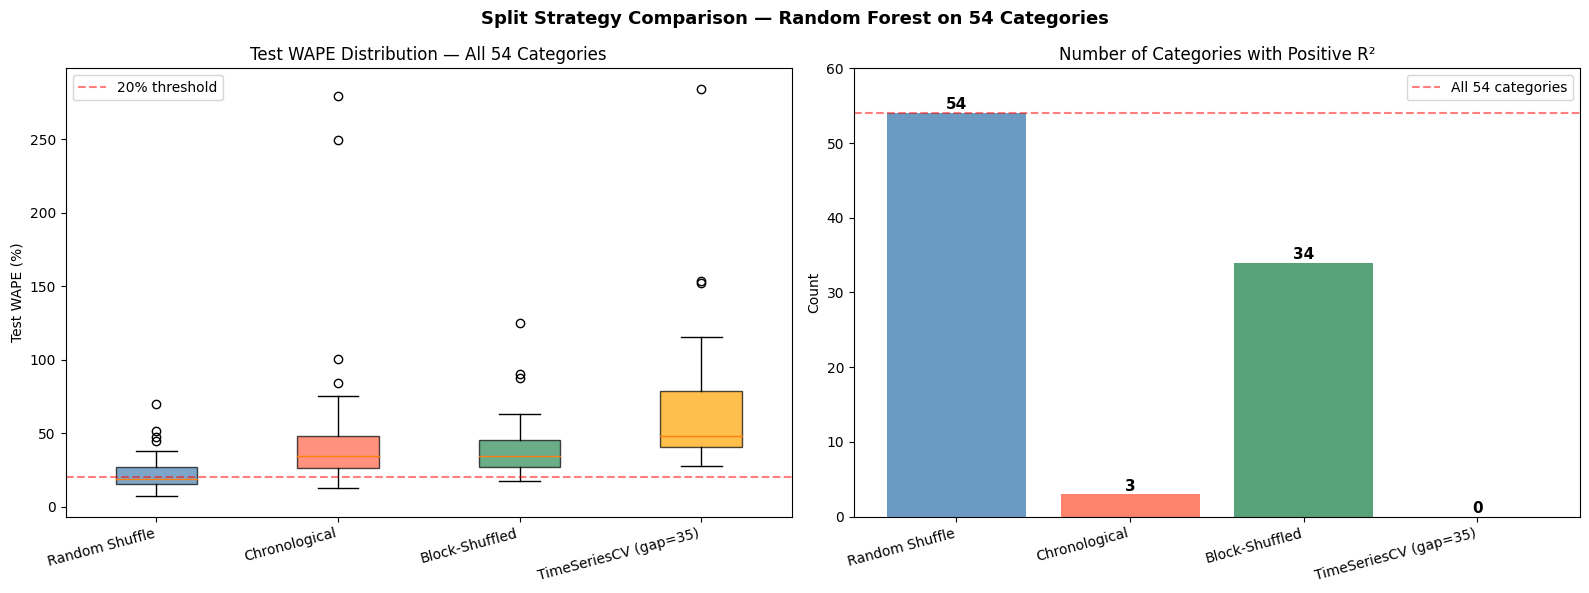

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

splits_order = ["Random Shuffle", "Chronological", 
                "Block-Shuffled", "TimeSeriesCV (gap=35)"]
colors = ["steelblue", "tomato", "seagreen", "orange"]

# ── Plot 1: WAPE boxplot ──
ax = axes[0]
data_to_plot = [
    split_comparison_df[
        split_comparison_df["Split"] == split
    ]["Test WAPE (%)"].dropna().values
    for split in splits_order
]
bp = ax.boxplot(data_to_plot, patch_artist=True, labels=splits_order)
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.axhline(y=20, color="red", linestyle="--", alpha=0.5, label="20% threshold")
ax.set_title("Test WAPE Distribution — All 54 Categories")
ax.set_ylabel("Test WAPE (%)")
ax.set_xticklabels(splits_order, rotation=15, ha="right")
ax.legend()

# ── Plot 2: Positive R² count ──
ax = axes[1]
positive_r2 = [
    (split_comparison_df[
        split_comparison_df["Split"] == split
    ]["Test R2"] > 0).sum()
    for split in splits_order
]
bars = ax.bar(splits_order, positive_r2, color=colors, alpha=0.8)
for bar, val in zip(bars, positive_r2):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        str(val),
        ha="center", fontsize=11, fontweight="bold"
    )
ax.axhline(y=54, color="red", linestyle="--", alpha=0.5, label="All 54 categories")
ax.set_title("Number of Categories with Positive R²")
ax.set_ylabel("Count")
ax.set_xticklabels(splits_order, rotation=15, ha="right")
ax.set_ylim(0, 60)
ax.legend()

plt.suptitle("Split Strategy Comparison — Random Forest on 54 Categories",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## Step 7: Leakage Risk Analysis

Beyond predictive performance, we quantify the leakage risk for each split.

Two rows share a leakage risk if their temporal distance is less than 
X-1 = 6 days, meaning their target windows overlap.

> Note: This measures target window overlap only. Feature-level leakage 
> (lag/rolling features sharing past values) is inherent to time series 
> modeling and is not counted here.

The leakage risk quantified here refers to target window overlap —
two rows whose prediction windows cover the same future days.
Feature-level leakage (lag/rolling features sharing past values)
is inherent to time series modeling and is not counted here.

In [46]:
overlap_dist = X_horizon - 1  # 6 days for X=7

leakage_results = []
data_ref = datasets[all_categories[0]]

for split_name, split_fn in {
    "Random Shuffle":  random_split,
    "Chronological":   chronological_split,
    "Block-Shuffled":  block_shuffled_split,
}.items():
    train, val, test = split_fn(data_ref)
    train_dates = pd.to_datetime(train["Date"].values)
    test_dates  = pd.to_datetime(test["Date"].values)
    contaminated = sum(
        1 for td in test_dates
        if np.any(np.abs((train_dates - td).days) < overlap_dist)
    )
    leakage_results.append({
        "Split":              split_name,
        "Test rows":          len(test_dates),
        "Contaminated rows":  contaminated,
        "Leakage (%)":        round(contaminated / len(test_dates) * 100, 1)
    })

leakage_results.append({
    "Split":             "TimeSeriesCV (gap=35)",
    "Test rows":         "-",
    "Contaminated rows": 0,
    "Leakage (%)":       0.0
})

leakage_df = pd.DataFrame(leakage_results)
leakage_df

,Split,Test rows,Contaminated rows,Leakage (%)
0,Random Shuffle,50,50,100.0
1,Chronological,67,0,0.0
2,Block-Shuffled,70,35,50.0
3,TimeSeriesCV (gap=35),-,0,0.0


## Step 8: Final Decision

### Summary

Two criteria were used to select the best split strategy:
1. **Predictive performance** — Test WAPE and R² across all 54 categories
2. **Leakage risk** — percentage of contaminated test rows

### Results Table

| Split | Avg Test WAPE | Positive R² | Leakage | Verdict |
|---|---|---|---|---|
| Random Shuffle | 22.35% | 54/54 | 100% | Rejected — severe leakage |
| Chronological | 46.90% | 3/54 | 0% | Rejected — distribution shift |
| Block-Shuffled | 38.66% | 34/54 | 50% | **Selected** |
| TimeSeriesCV | 62.75% | 0/54 | 0% | Rejected — insufficient data per fold |

### Conclusion

**Block-Shuffled is selected as the final split strategy.**

No split is perfect on this one-year dataset:
- Random Shuffle gives the best metrics but with 100% leakage — 
  not scientifically defensible
- Chronological and TimeSeriesCV are clean but produce unusable 
  results — only 3/54 and 0/54 categories with positive R²
- Block-Shuffled is the only strategy that gives both exploitable 
  metrics (34/54 positive R²) and a documented, bounded leakage risk

### Limitation

Results from the Block-Shuffled split should be interpreted as an 
**optimistic upper bound** of real deployment performance due to the 
residual 50% leakage. With several years of data, a chronological 
or TimeSeriesCV split would be more appropriate.

> This notebook serves as the methodological justification for the 
> split choice used in the